In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import sklearn
import warnings
warnings.filterwarnings("ignore")

In [2]:
ghana = pd.read_csv("../DATASETS/earthquake/Ghana-catalog_update-2022-04.csv")

In [5]:
ghana.head(15)

,eventID,year,month,day,hour,minute,second,latitude,longitude,depth,...,magnitude,location,Ref.,RMS(sec),Mag,Error,Depth,Error.1,Duplicate,Type
0,1,1615,2,21,12,5,19.3,5.1,-1.30,8.0,...,5.5,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1636,12,18,14,49,6.6,5.1,-2.20,8.0,...,5.7,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1788,4,23,5,43,22.4,7.6,1.70,10.0,...,5.6,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1836,12,29,23,55,19.7,5.1,-1.30,15.0,...,5.0,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1858,8,21,3,30,20.4,5.6,-0.20,11.0,...,4.5,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,1861,6,6,6,39,48.8,6.0,0.00,16.0,...,4.5,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,1862,7,10,8,53,31.7,5.5,-0.25,18.0,...,6.8,BGS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,1870,11,23,12,19,31.1,5.3,-0.70,11.0,...,4.5,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,1871,1,26,20,8,46.3,5.5,-0.40,7.0,...,4.6,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,1872,4,14,23,55,7.1,5.5,-0.40,13.0,...,4.9,NNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data inspection and cleaning

In [5]:
ghana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   eventID         302 non-null    int64  
 1   year            302 non-null    int64  
 2   month           302 non-null    int64  
 3   day             302 non-null    int64  
 4   hour            302 non-null    int64  
 5   minute          302 non-null    int64  
 6   second          302 non-null    float64
 7   latitude        302 non-null    float64
 8   longitude       302 non-null    float64
 9   depth           302 non-null    float64
 10  Unnamed: 10     0 non-null      float64
 11  Unnamed: 11     0 non-null      float64
 12  sigmaMagnitude  302 non-null    float64
 13  magnitude       302 non-null    float64
 14  location        302 non-null    object 
 15  Ref.            0 non-null      float64
 16  RMS(sec)        0 non-null      float64
 17  Mag             0 non-null      flo

In [6]:
ghana.isnull().sum()

eventID             0
year                0
month               0
day                 0
hour                0
minute              0
second              0
latitude            0
longitude           0
depth               0
Unnamed: 10       302
Unnamed: 11       302
sigmaMagnitude      0
magnitude           0
location            0
Ref.              302
RMS(sec)          302
Mag               302
Error             302
Depth             302
Error.1           302
Duplicate         302
Type              302
dtype: int64

In [7]:
### droping the null columns
ghana.dropna(axis=1, inplace=True)

In [8]:
ghana.head(3)

,eventID,year,month,day,hour,minute,second,latitude,longitude,depth,sigmaMagnitude,magnitude,location
0,1,1615,2,21,12,5,19.3,5.1,-1.3,8.0,0.3,5.5,NNA
1,2,1636,12,18,14,49,6.6,5.1,-2.2,8.0,0.3,5.7,NNA
2,3,1788,4,23,5,43,22.4,7.6,1.7,10.0,0.3,5.6,NNA


In [9]:
ghana

,eventID,year,month,day,hour,minute,second,latitude,longitude,depth,sigmaMagnitude,magnitude,location
0,1,1615,2,21,12,5,19.30,5.1000,-1.3000,8.0,0.3,5.5,NNA
1,2,1636,12,18,14,49,6.60,5.1000,-2.2000,8.0,0.3,5.7,NNA
2,3,1788,4,23,5,43,22.40,7.6000,1.7000,10.0,0.3,5.6,NNA
3,4,1836,12,29,23,55,19.70,5.1000,-1.3000,15.0,0.3,5.0,NNA
4,5,1858,8,21,3,30,20.40,5.6000,-0.2000,11.0,0.3,4.5,NNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,298,2016,7,21,0,54,39.46,7.3605,-2.8692,0.0,0.3,2.0,ISC
298,299,2018,12,9,7,49,49.60,5.6849,-0.4578,0.0,0.3,2.0,ISC
299,300,2019,8,28,15,41,18.77,7.1715,-1.6102,0.0,0.3,2.7,ISC
300,301,2020,4,24,22,47,55.41,5.9495,-0.4048,0.0,0.3,3.4,ISC


In [10]:
### Remove irrelevant columns
ghana = ghana.drop(columns=["eventID", "year", "day", "month", "minute", "second", "sigmaMagnitude", "sigmaMagnitude","location", "hour"])

In [11]:
ghana

,latitude,longitude,depth,magnitude
0,5.1000,-1.3000,8.0,5.5
1,5.1000,-2.2000,8.0,5.7
2,7.6000,1.7000,10.0,5.6
3,5.1000,-1.3000,15.0,5.0
4,5.6000,-0.2000,11.0,4.5
...,...,...,...,...
297,7.3605,-2.8692,0.0,2.0
298,5.6849,-0.4578,0.0,2.0
299,7.1715,-1.6102,0.0,2.7
300,5.9495,-0.4048,0.0,3.4


## Creating the earthquake categories
- **Micro (<3.0): Generally not felt by people**
- **Minor (3.0-3.9): Often felt, rarely causes damage**
- **Light (4.0-4.9): May cause minor damage**
- **Moderate (5.0-5.9): Can cause noticeable damage**
- **Strong (6.0-6.9): May result in severe damage in populated areas**
- **Major (7.0-7.9): Typically causes widespread destruction**
- **Great (8.0+): Catastrophic, capable of massive devastation**

In [12]:
def create_magnitude_categories(df):
    temp_df = df.copy()
    bins = [0,3, 4, 5, 6, 7, 8, 9]
    labels = ["micro", "minor", "light", "moderate", "strong", "major", "great"]
    temp_df["magnitude_category"] = pd.cut(x=temp_df["magnitude"], bins=bins, labels=labels)
    return temp_df

In [13]:
ghana = create_magnitude_categories(ghana)
ghana

,latitude,longitude,depth,magnitude,magnitude_category
0,5.1000,-1.3000,8.0,5.5,moderate
1,5.1000,-2.2000,8.0,5.7,moderate
2,7.6000,1.7000,10.0,5.6,moderate
3,5.1000,-1.3000,15.0,5.0,light
4,5.6000,-0.2000,11.0,4.5,light
...,...,...,...,...,...
297,7.3605,-2.8692,0.0,2.0,micro
298,5.6849,-0.4578,0.0,2.0,micro
299,7.1715,-1.6102,0.0,2.7,micro
300,5.9495,-0.4048,0.0,3.4,minor


## Visualizations Ghana Dataset

In [14]:
sns.set_theme()

<Axes: xlabel='magnitude_category'>

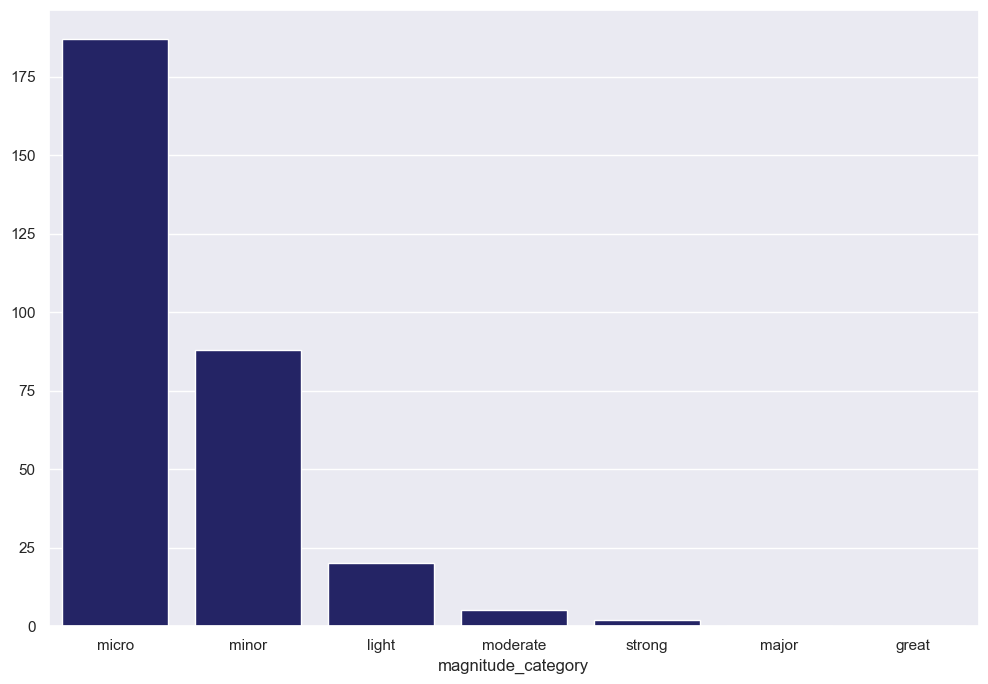

In [15]:
ghana_mag_cat = ghana["magnitude_category"].value_counts()
plt.figure(figsize=(12,8))
sns.barplot(x=ghana_mag_cat.index, y=ghana_mag_cat.values, color="midnightblue")

<Axes: xlabel='magnitude', ylabel='depth'>

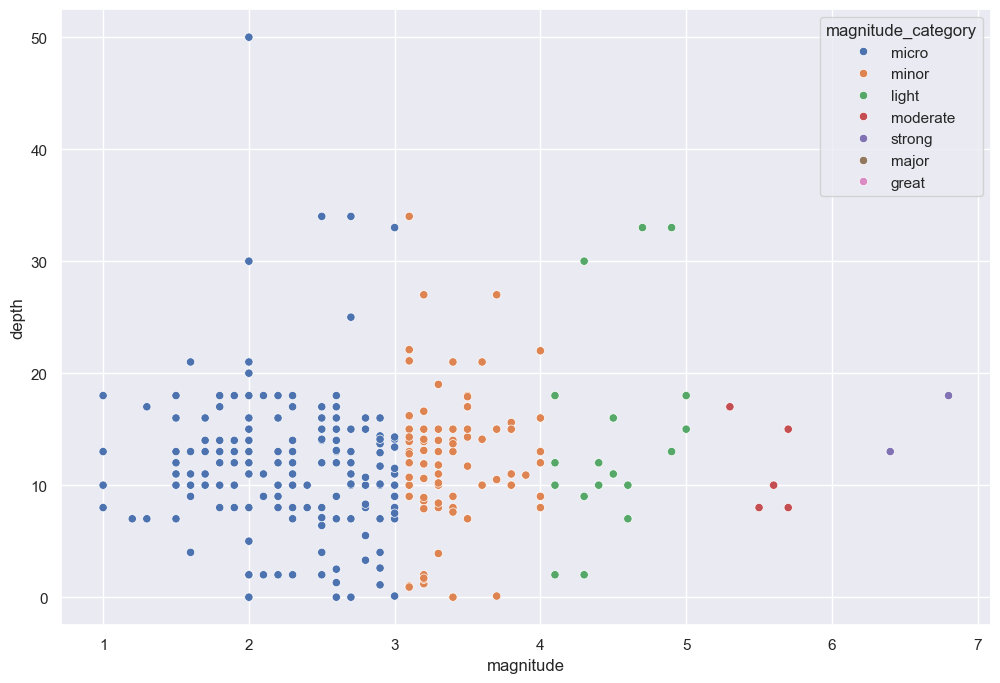

In [16]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=ghana, x="magnitude", y="depth", hue="magnitude_category")

<Axes: >

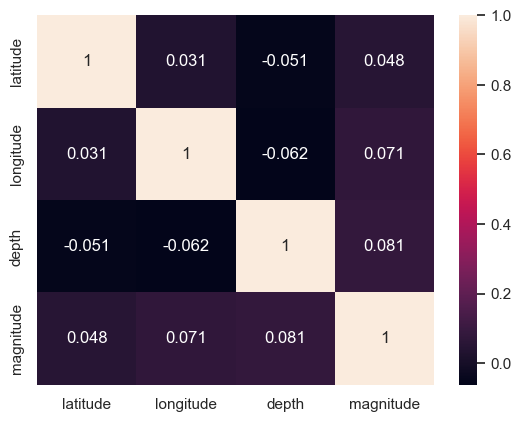

In [17]:
corr_coef =  ghana.select_dtypes(exclude="category").corr()
sns.heatmap(data=corr_coef, annot=True)

<Axes: xlabel='magnitude', ylabel='Count'>

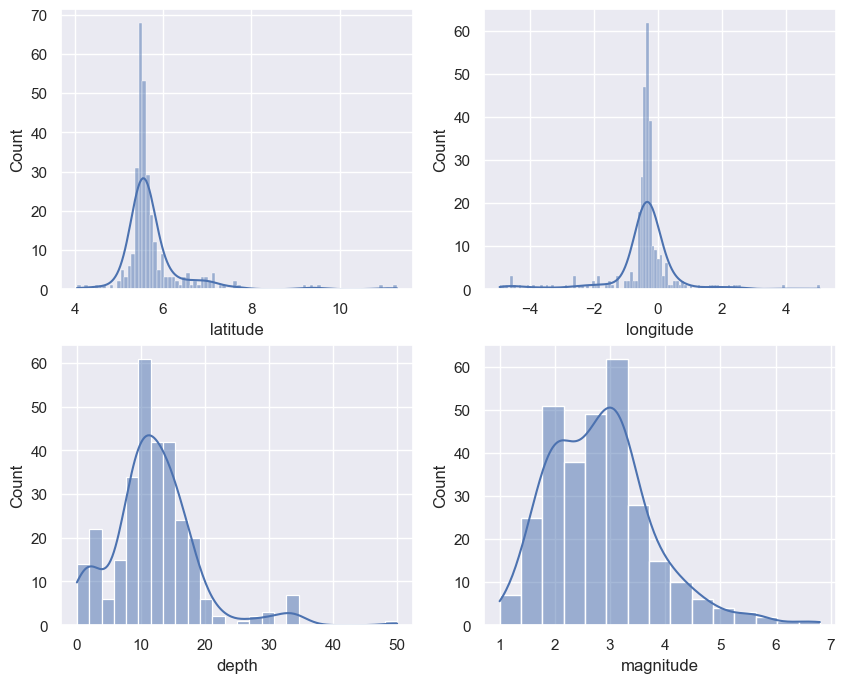

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax1, ax2, ax3, ax4 = ax.flatten()
sns.histplot(data=ghana, x="latitude", ax=ax1, kde=True)
sns.histplot(data=ghana, x="longitude", ax=ax2,  kde=True)
sns.histplot(data=ghana, x="depth", ax=ax3,  kde=True)
sns.histplot(data=ghana, x="magnitude", ax=ax4,  kde=True)


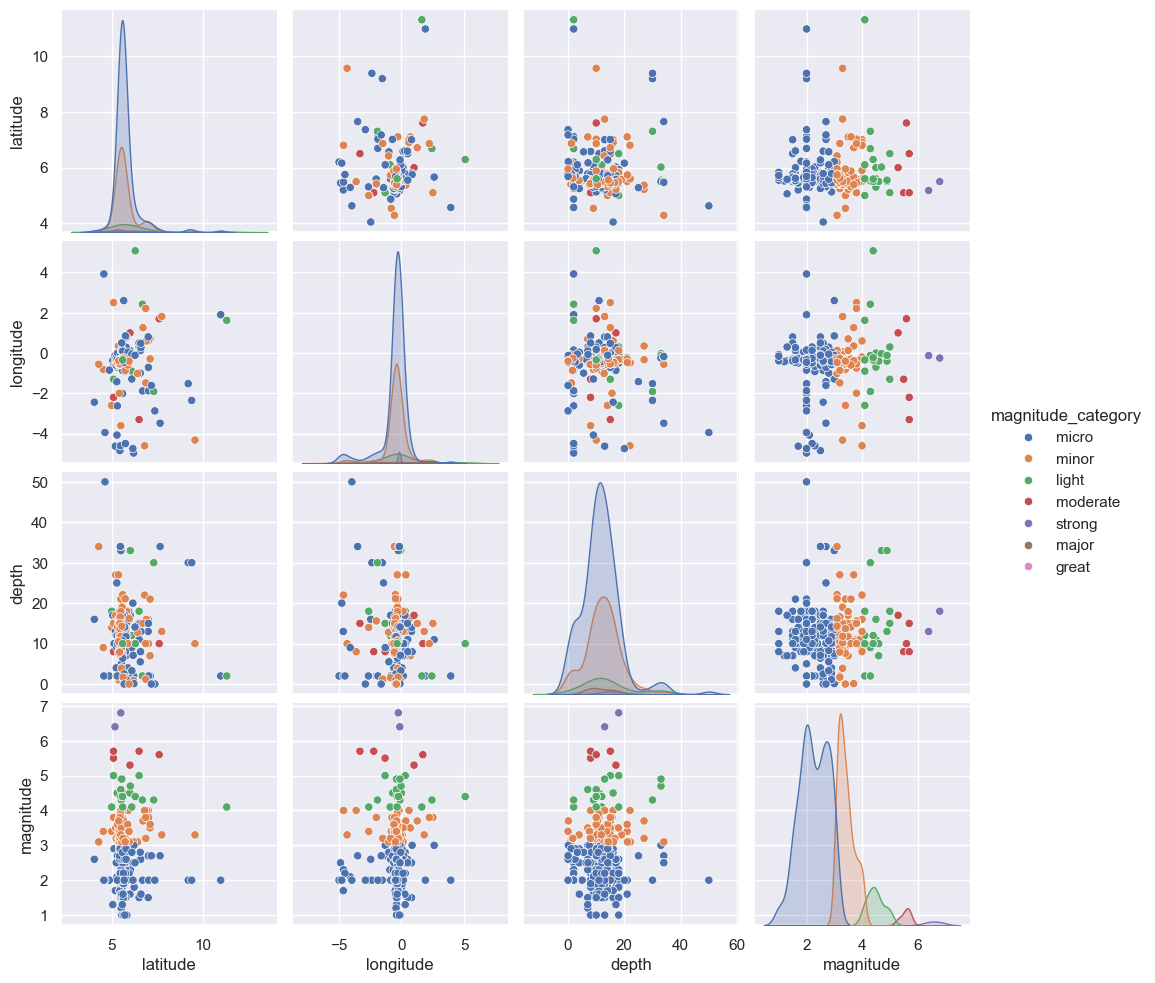

In [19]:
sns.pairplot(data=ghana, hue="magnitude_category")

# Working on Global Dataset

In [20]:
source = pd.read_csv("../DATASETS/earthquake/earthquakes.csv")
source.head()

,id,impact.gap,impact.magnitude,impact.significance,location.depth,location.distance,location.full,location.latitude,location.longitude,location.name,time.day,time.epoch,time.full,time.hour,time.minute,time.month,time.second,time.year
0,nc72666881,122.00,1.43,31,15.12,0.10340,"13km E of Livermore, California",37.672333,-121.619000,California,27,1469593183550,2016-07-27 00:19:43,0,19,7,43,2016
1,us20006i0y,30.00,4.90,371,97.07,1.43900,"58km WNW of Pakokku, Burma",21.514600,94.572100,Burma,27,1469593228220,2016-07-27 00:20:28,0,20,7,28,2016
2,nc72666891,249.00,0.06,0,4.39,0.02743,"12km SE of Mammoth Lakes, California",37.576500,-118.859167,California,27,1469593897150,2016-07-27 00:31:37,0,31,7,37,2016
3,nc72666896,122.00,0.40,2,1.09,0.02699,"6km SSW of Mammoth Lakes, California",37.595833,-118.994833,California,27,1469594144150,2016-07-27 00:35:44,0,35,7,44,2016
4,nn00553447,113.61,0.30,1,7.60,0.06300,"16km SSE of Mogul, Nevada",39.377500,-119.845000,Nevada,27,1469594519667,2016-07-27 00:41:59,0,41,7,59,2016


In [21]:
source.head()

,id,impact.gap,impact.magnitude,impact.significance,location.depth,location.distance,location.full,location.latitude,location.longitude,location.name,time.day,time.epoch,time.full,time.hour,time.minute,time.month,time.second,time.year
0,nc72666881,122.00,1.43,31,15.12,0.10340,"13km E of Livermore, California",37.672333,-121.619000,California,27,1469593183550,2016-07-27 00:19:43,0,19,7,43,2016
1,us20006i0y,30.00,4.90,371,97.07,1.43900,"58km WNW of Pakokku, Burma",21.514600,94.572100,Burma,27,1469593228220,2016-07-27 00:20:28,0,20,7,28,2016
2,nc72666891,249.00,0.06,0,4.39,0.02743,"12km SE of Mammoth Lakes, California",37.576500,-118.859167,California,27,1469593897150,2016-07-27 00:31:37,0,31,7,37,2016
3,nc72666896,122.00,0.40,2,1.09,0.02699,"6km SSW of Mammoth Lakes, California",37.595833,-118.994833,California,27,1469594144150,2016-07-27 00:35:44,0,35,7,44,2016
4,nn00553447,113.61,0.30,1,7.60,0.06300,"16km SSE of Mogul, Nevada",39.377500,-119.845000,Nevada,27,1469594519667,2016-07-27 00:41:59,0,41,7,59,2016


In [22]:

source.shape

(8394, 18)

In [23]:
### Eliminating irrelevant Columns
source = source[["impact.magnitude", "location.depth", "location.latitude", "location.longitude"]]
source

,impact.magnitude,location.depth,location.latitude,location.longitude
0,1.43,15.12,37.672333,-121.619000
1,4.90,97.07,21.514600,94.572100
2,0.06,4.39,37.576500,-118.859167
3,0.40,1.09,37.595833,-118.994833
4,0.30,7.60,39.377500,-119.845000
...,...,...,...,...
8389,2.42,4.85,36.515499,-121.099831
8390,1.40,50.00,61.498400,-149.862700
8391,1.06,1.73,38.805000,-122.821503
8392,1.55,29.25,34.308000,-118.635333


In [24]:
source = source.rename(columns={"impact.magnitude": "magnitude", "location.depth": "depth", "location.latitude": "latitude", "location.longitude": "longitude"})

In [25]:
source

,magnitude,depth,latitude,longitude
0,1.43,15.12,37.672333,-121.619000
1,4.90,97.07,21.514600,94.572100
2,0.06,4.39,37.576500,-118.859167
3,0.40,1.09,37.595833,-118.994833
4,0.30,7.60,39.377500,-119.845000
...,...,...,...,...
8389,2.42,4.85,36.515499,-121.099831
8390,1.40,50.00,61.498400,-149.862700
8391,1.06,1.73,38.805000,-122.821503
8392,1.55,29.25,34.308000,-118.635333


In [26]:
source.drop_duplicates(inplace=True)

In [27]:
source = create_magnitude_categories(source)
source

,magnitude,depth,latitude,longitude,magnitude_category
0,1.43,15.12,37.672333,-121.619000,micro
1,4.90,97.07,21.514600,94.572100,light
2,0.06,4.39,37.576500,-118.859167,micro
3,0.40,1.09,37.595833,-118.994833,micro
4,0.30,7.60,39.377500,-119.845000,micro
...,...,...,...,...,...
8389,2.42,4.85,36.515499,-121.099831,micro
8390,1.40,50.00,61.498400,-149.862700,micro
8391,1.06,1.73,38.805000,-122.821503,micro
8392,1.55,29.25,34.308000,-118.635333,micro


# Visualization of Global Dataset

<Axes: xlabel='magnitude_category'>

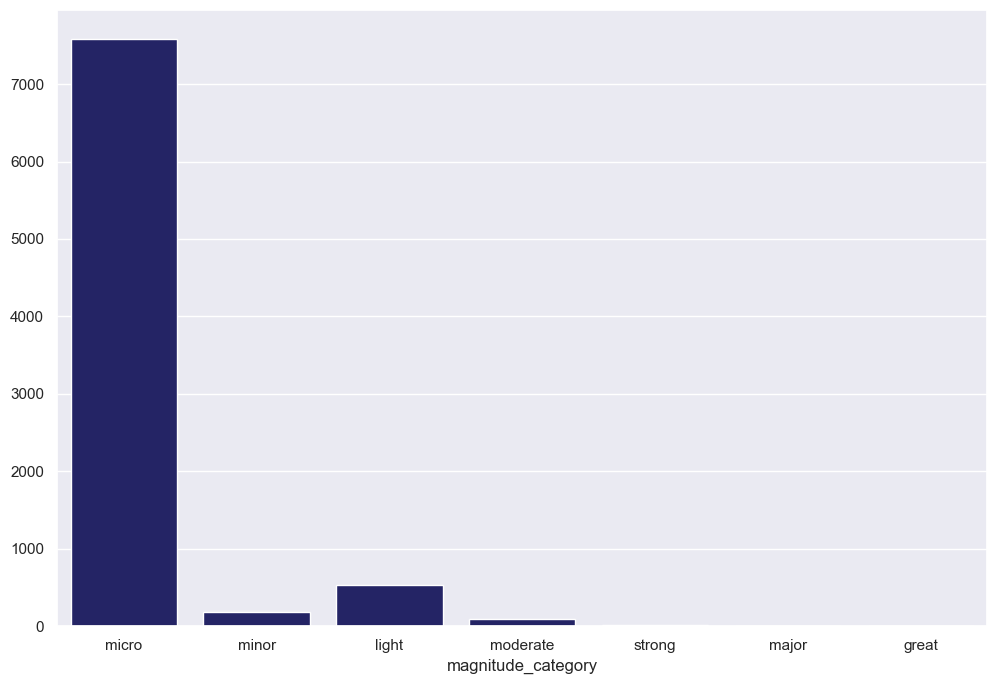

In [28]:
source_mag_cat = source["magnitude_category"].value_counts()
plt.figure(figsize=(12,8))
sns.barplot(x=source_mag_cat.index, y=source_mag_cat.values, color="midnightblue")

<Axes: xlabel='magnitude', ylabel='depth'>

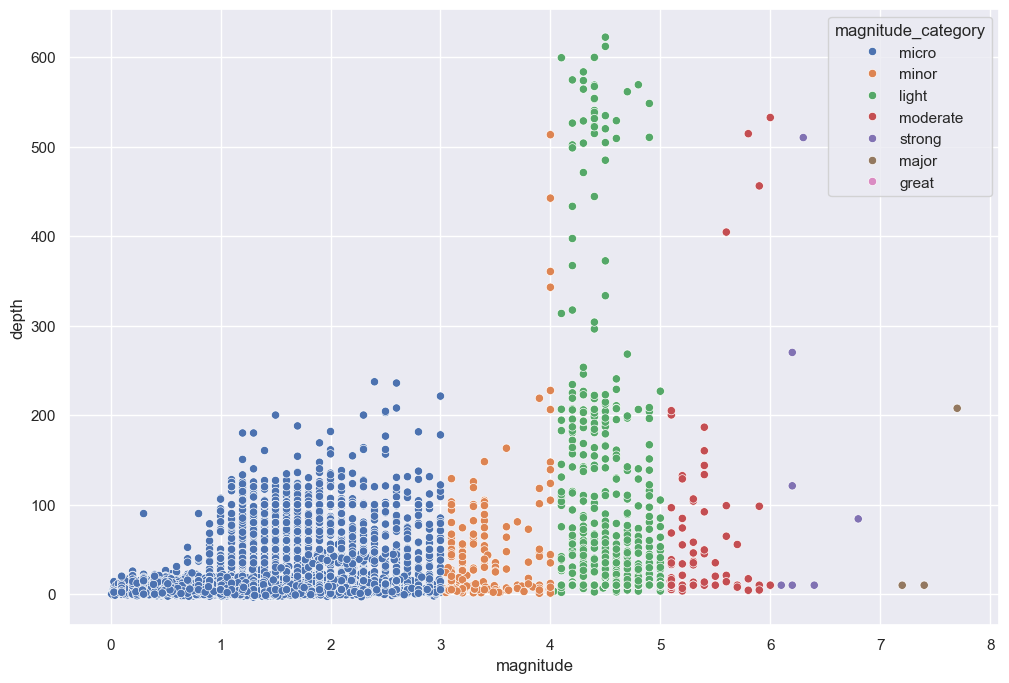

In [29]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=source, x="magnitude", y="depth", hue="magnitude_category")

<Axes: >

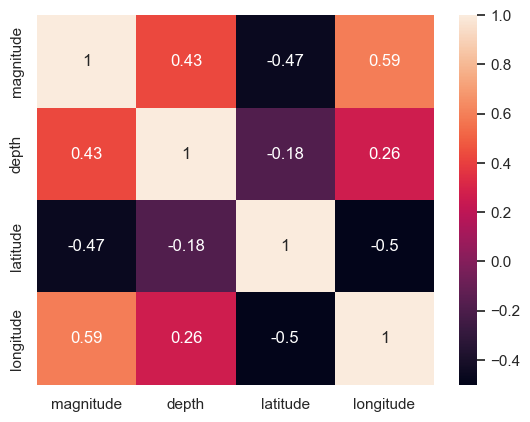

In [30]:
corr_coef_source =  source.select_dtypes(exclude="category").corr()
sns.heatmap(data=corr_coef_source, annot=True)

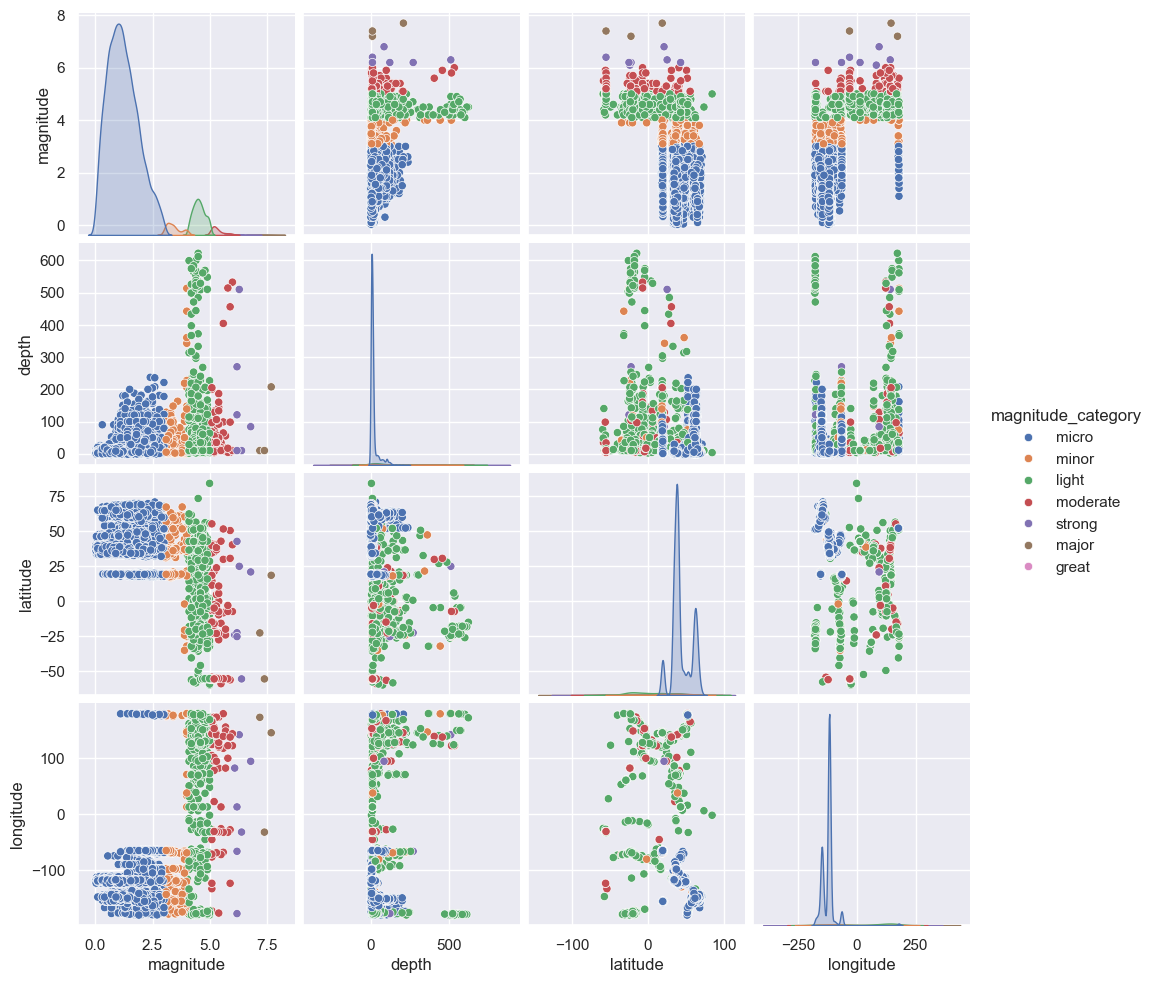

In [31]:
sns.pairplot(data=source, hue="magnitude_category")

<Axes: xlabel='magnitude', ylabel='Count'>

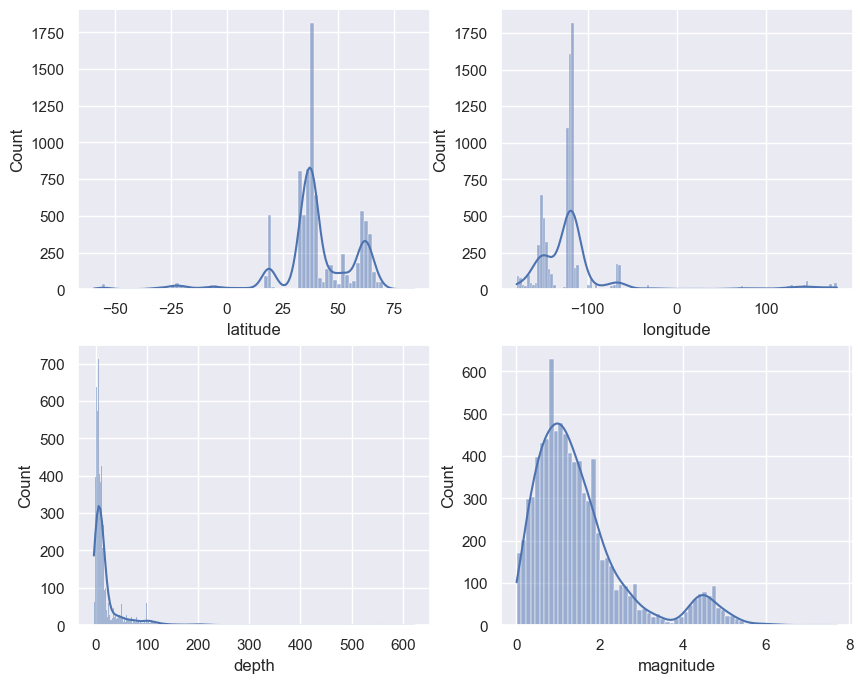

In [32]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax1, ax2, ax3, ax4 = ax.flatten()
sns.histplot(data=source, x="latitude", ax=ax1, kde=True)
sns.histplot(data=source, x="longitude", ax=ax2,  kde=True)
sns.histplot(data=source, x="depth", ax=ax3,  kde=True)
sns.histplot(data=source, x="magnitude", ax=ax4,  kde=True)


# MODEL TRAINING

In [33]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
source_input = source.drop(["magnitude", "magnitude_category"], axis=1)
source_output = source["magnitude"]

In [35]:
source_X_train, source_X_test, source_Y_train, source_Y_test = train_test_split(source_input, source_output, test_size=0.3, random_state=42)

# Label encoding and standard scaling

In [36]:
num_cols = source_X_train.select_dtypes(include="float64").columns
# cat_cols = source_X_train.select_dtypes(exclude="float64").columns

### label Encoding for the magnitude category columns
# mag_cat_le= LabelEncoder() 
# source_X_train["magnitude_category"] = mag_cat_le.fit_transform(source_X_train["magnitude_category"])
# source_X_test["magnitude_category"] = mag_cat_le.transform(source_X_test["magnitude_category"])

In [37]:
### Scaling
scaler = StandardScaler()
source_X_train[num_cols] = scaler.fit_transform(source_X_train[num_cols])
source_X_test[num_cols] = scaler.transform(source_X_test[num_cols])

In [38]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r_score = r2_score(true, predicted)
    return mae, mse, r_score

In [39]:
base_performance={}

In [40]:
models={
    "svr" : SVR(),
    "random Forest": RandomForestRegressor(),
    "adaboost": AdaBoostRegressor(),
    "gradient boosting": GradientBoostingRegressor(),
    "xgboost": XGBRegressor()
}


for i in range(len(list(models))):
    model = list(models.values())[i]
    name = list(models.keys())[i]
    model.fit(source_X_train, source_Y_train)
    y_train_pred= model.predict(source_X_train)
    y_test_pred = model.predict(source_X_test)

    print(f"predictions from {list(models.keys())[i]}")
    train_mae, train_mse, train_r_score = evaluate_model(source_Y_train, y_train_pred)
    test_mae, test_mse, test_r_score = evaluate_model(source_Y_test, y_test_pred)
    base_performance[name] = {
        "train": [train_mae, train_mse, train_r_score],
        "test" : [test_mae, test_mse, test_r_score]
    } 
    print(f"Predictions from training:   ")
    print(f"mae:  {train_mae} ")
    print(f"mse: {train_mse}")
    print(f"r2_score: {train_r_score}")

    print("--------------------------------------------------------------------")

    print(f"Predictions from texting: ")
    print(f"mae:  {test_mae} ")
    print(f"mse: {test_mse}")
    print(f"r2_score: {test_r_score}")


    print("=================================================================")

predictions from svr
Predictions from training:   
mae:  0.4460407999196511 
mse: 0.3677877215645442
r2_score: 0.7256890054198011
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.461727252272562 
mse: 0.3924563300049277
r2_score: 0.6991213541794405
predictions from random Forest
Predictions from training:   
mae:  0.13656570395256487 
mse: 0.035335208274449435
r2_score: 0.9736455690140224
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.36211882886037294 
mse: 0.23990725329915844
r2_score: 0.816073881406692
predictions from adaboost
Predictions from training:   
mae:  0.5756787630812378 
mse: 0.47961372074050973
r2_score: 0.6422846412844411
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.5735845593458498 
mse: 0.4788230556919957
r2_score: 0.6329078637043233
predictions from gradient boosting
Predictions from training:   
m

In [41]:
base_performance

{'svr': {'train': [0.4460407999196511, 0.3677877215645442, 0.7256890054198011],
  'test': [0.461727252272562, 0.3924563300049277, 0.6991213541794405]},
 'random Forest': {'train': [0.13656570395256487,
   0.035335208274449435,
   0.9736455690140224],
  'test': [0.36211882886037294, 0.23990725329915844, 0.816073881406692]},
 'adaboost': {'train': [0.5756787630812378,
   0.47961372074050973,
   0.6422846412844411],
  'test': [0.5735845593458498, 0.4788230556919957, 0.6329078637043233]},
 'gradient boosting': {'train': [0.3832958584561232,
   0.259497324681746,
   0.806456374015035],
  'test': [0.39650883908469164, 0.28002462844538073, 0.785317691265182]},
 'xgboost': {'train': [0.23905778093419677,
   0.10623555529981042,
   0.9207652155702631],
  'test': [0.37406667799077375, 0.2538202838967804, 0.8054073855817427]}}

In [42]:
# Define metric names
metrics = ["MAE", "MSE", "R2_Score"]

# Convert dict to long DataFrame
rows = []
for model, scores in base_performance.items():
    for dataset_type, values in scores.items():
        for metric, value in zip(metrics, values):
            rows.append({
                "models": model,
                "dataset": dataset_type,
                "Metric": metric,
                "Value": value
            })

print(rows)
performance_df = pd.DataFrame(rows)
performance_df

[{'models': 'svr', 'dataset': 'train', 'Metric': 'MAE', 'Value': 0.4460407999196511}, {'models': 'svr', 'dataset': 'train', 'Metric': 'MSE', 'Value': 0.3677877215645442}, {'models': 'svr', 'dataset': 'train', 'Metric': 'R2_Score', 'Value': 0.7256890054198011}, {'models': 'svr', 'dataset': 'test', 'Metric': 'MAE', 'Value': 0.461727252272562}, {'models': 'svr', 'dataset': 'test', 'Metric': 'MSE', 'Value': 0.3924563300049277}, {'models': 'svr', 'dataset': 'test', 'Metric': 'R2_Score', 'Value': 0.6991213541794405}, {'models': 'random Forest', 'dataset': 'train', 'Metric': 'MAE', 'Value': 0.13656570395256487}, {'models': 'random Forest', 'dataset': 'train', 'Metric': 'MSE', 'Value': 0.035335208274449435}, {'models': 'random Forest', 'dataset': 'train', 'Metric': 'R2_Score', 'Value': 0.9736455690140224}, {'models': 'random Forest', 'dataset': 'test', 'Metric': 'MAE', 'Value': 0.36211882886037294}, {'models': 'random Forest', 'dataset': 'test', 'Metric': 'MSE', 'Value': 0.23990725329915844}, 

,models,dataset,Metric,Value
0,svr,train,MAE,0.446041
1,svr,train,MSE,0.367788
2,svr,train,R2_Score,0.725689
3,svr,test,MAE,0.461727
4,svr,test,MSE,0.392456
5,svr,test,R2_Score,0.699121
6,random Forest,train,MAE,0.136566
7,random Forest,train,MSE,0.035335
8,random Forest,train,R2_Score,0.973646
9,random Forest,test,MAE,0.362119


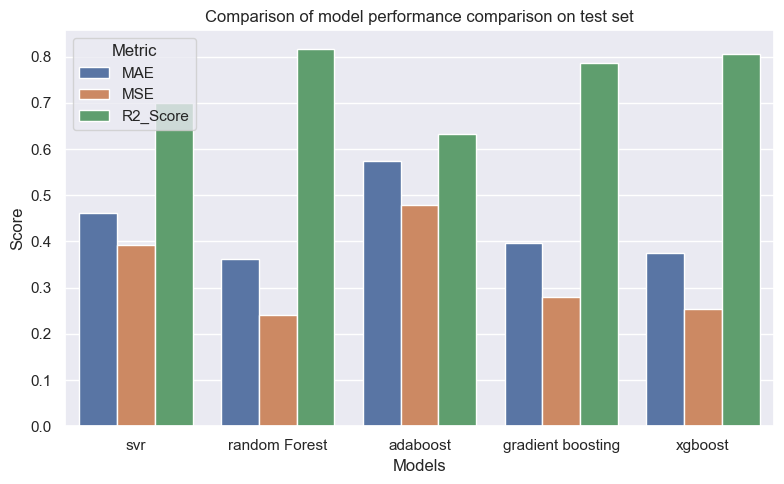

In [43]:
df_long_test= performance_df[performance_df["dataset"] == "test"]

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_long_test, x='models', y='Value', hue='Metric')

plt.title('Comparison of model performance comparison on test set')
plt.ylabel('Score')
plt.xlabel('Models')
plt.legend(title='Metric', loc="upper left")
plt.tight_layout()
plt.show()

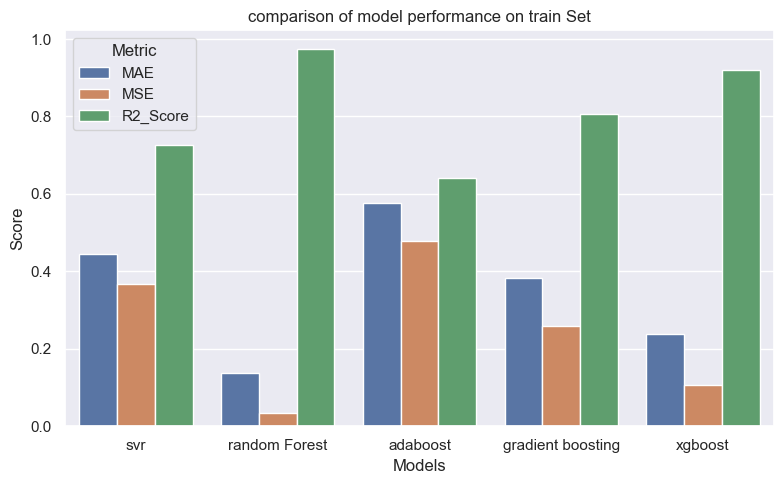

In [44]:
df_long_train= performance_df[performance_df["dataset"] == "train"]

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_long_train, x='models', y='Value', hue='Metric')
plt.title('comparison of model performance on train Set')
plt.ylabel('Score')
plt.xlabel('Models')
plt.legend(title='Metric', loc="upper left")
plt.tight_layout()
plt.show()

In [45]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [46]:
rf_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, None, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'max_features': ['auto', 'sqrt', 'log2'],
}

xg_params={
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
    'reg_lambda': [0.1, 1, 10]
}

gb_params = {
    'n_estimators': [50, 100, 200, 300, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3,4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 5],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['auto', 'sqrt', 'log2', None]

}


model_params = {}
random_search_model = [
   ("rf", RandomForestRegressor(), rf_params),
    ("xgboost", XGBRegressor(), xg_params),
    ("gradient", GradientBoostingRegressor(), gb_params),
   
]

# for name, estimator, param in random_search_model:
#     random = RandomizedSearchCV(estimator=estimator, param_distributions=param, scoring='neg_mean_squared_error', verbose=1, n_iter=100, cv=10, n_jobs=-1,random_state=42)

#     random.fit(source_X_train, source_Y_train)
#     model_params[name] = random.best_params_

# for model_name in model_params:
#     print(f"best parameters for {model_name} ")
#     print(model_params[model_name])

In [47]:
# svr_params = {
#     'C': [0.01, 0.1, 1, 10, 100, 1000],  # Wider range
#     'epsilon': [0.0001, 0.001, 0.01, 0.1, 1],
#     'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
#     'degree': [2, 3, 4, 5, 6],  # Only relevant for 'poly'
#     'coef0': [0.0, 0.1, 0.5, 1.0],  # For 'poly' and 'sigmoid'
#     'shrinking': [True, False],
#     'max_iter': [-1, 1000, 5000, 10000]
# }

# svr_model_params = {}

# svr_random_search_model = [
#     ("svr",  SVR(), svr_params)
# ]

# for name, estimator, param in svr_random_search_model:
#     random = RandomizedSearchCV(estimator=estimator, param_distributions=param, scoring='neg_mean_squared_error', verbose=1, n_iter=100, cv=10, n_jobs=-1,random_state=42)

#     random.fit(source_X_train, source_Y_train)
#     svr_model_params[name] = random.best_params_

# for model_name in svr_model_params:
#     print(f"best parameters for {model_name} ")
#     print(model_params[model_name])

predictions from random Forest
Predictions from training:   
mae:  0.25675703414243856 
mse: 0.12596289945668876
r2_score: 0.9060517624591062
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.3599981700894381 
mse: 0.2364114542769766
r2_score: 0.81875395354578


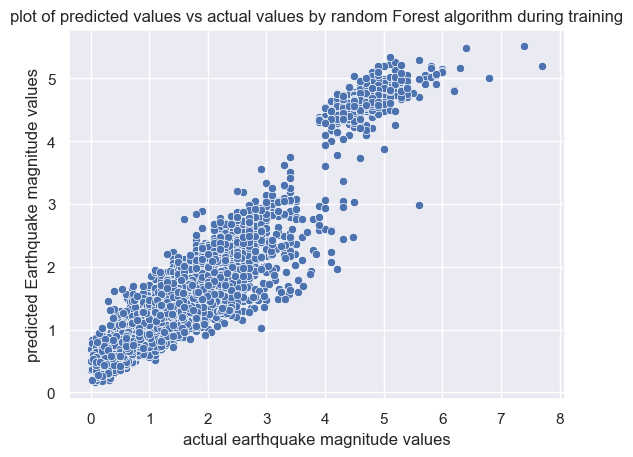

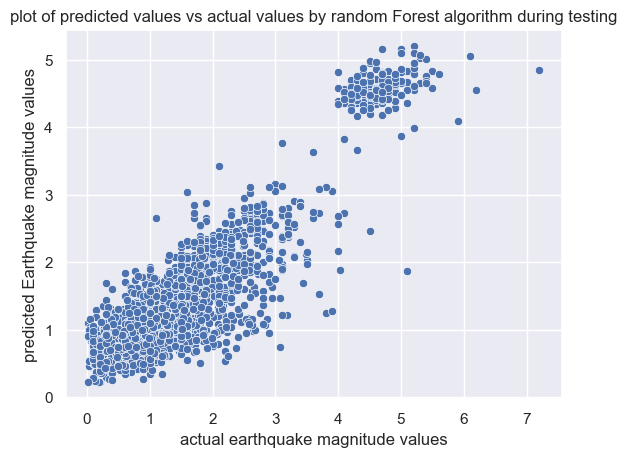

predictions from gradient boosting
Predictions from training:   
mae:  0.2787152872993279 
mse: 0.1441501470814852
r2_score: 0.8924869757843049
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.3598090416717476 
mse: 0.2373886133476971
r2_score: 0.8180048095634521


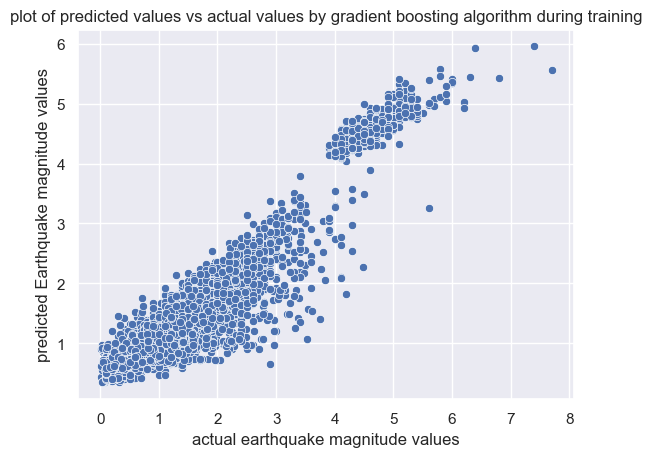

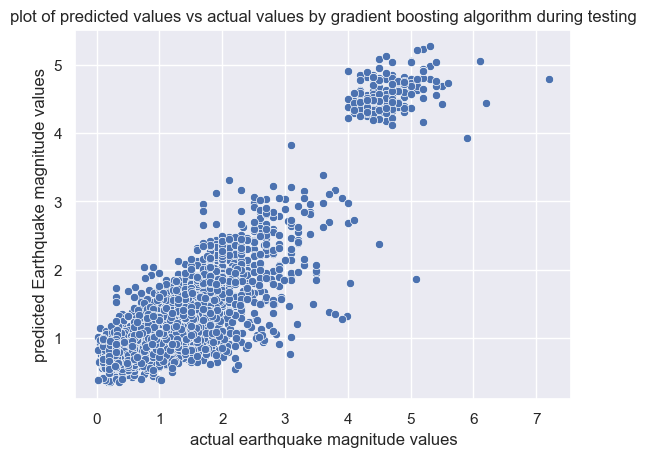

predictions from xgboost
Predictions from training:   
mae:  0.28299379793250323 
mse: 0.14732764927972547
r2_score: 0.8901170658140312
--------------------------------------------------------------------
Predictions from texting: 
mae:  0.36119986346681465 
mse: 0.2384390818639216
r2_score: 0.8171994625210569


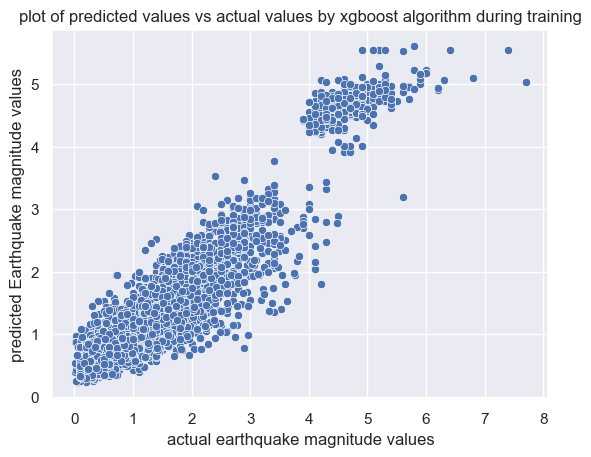

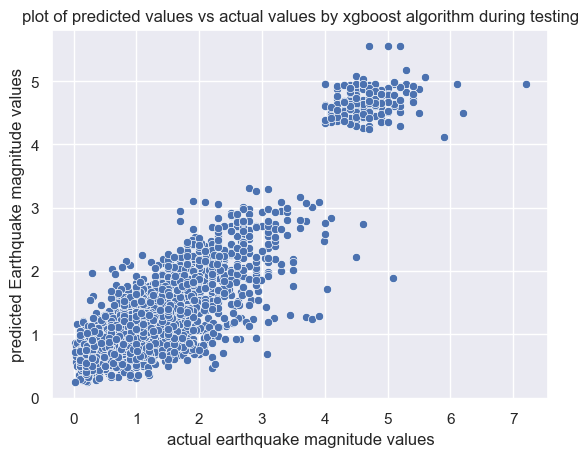

In [ ]:
models={
# "random Forest": RandomForestRegressor(n_estimators= 300, min_samples_split= 10, min_samples_leaf= 4, max_depth=15, bootstrap=True),
"random Forest": RandomForestRegressor(n_estimators= 500, min_samples_split= 10, min_samples_leaf= 2, max_depth=None, bootstrap=True, max_features="sqrt"),

# "gradient boosting": GradientBoostingRegressor(subsample= 0.6, n_estimators= np.int64(150), min_samples_split= 2, min_samples_leaf=2,
#                                                max_features= None, max_depth=np.int64(7), learning_rate= 0.05),
"gradient boosting": GradientBoostingRegressor(subsample= 0.6, n_estimators= 400, min_samples_split= 2, min_samples_leaf=5,
                                            max_features= None, max_depth=10, learning_rate= 0.01 ),
"xgboost": XGBRegressor(
    subsample=0.8, reg_lambda=10, reg_alpha=0.01, n_estimators=400, max_depth=15, learning_rate=0.05, gamma=0.2, colsample_bytree=1.0, 

    )
}

scores = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model_name = list(models.keys())[i]

    model.fit(source_X_train, source_Y_train)
    y_train_pred= model.predict(source_X_train)
    y_test_pred = model.predict(source_X_test)

    print(f"predictions from {list(models.keys())[i]}")
    train_mae, train_mse, train_r_score = evaluate_model(source_Y_train, y_train_pred)
    test_mae, test_mse, test_r_score = evaluate_model(source_Y_test, y_test_pred)

    print(f"Predictions from training:   ")
    print(f"mae:  {train_mae} ")
    print(f"mse: {train_mse}")
    print(f"r2_score: {train_r_score}")

    print("--------------------------------------------------------------------")

    print(f"Predictions from texting: ")
    print(f"mae:  {test_mae} ")
    print(f"mse: {test_mse}")
    print(f"r2_score: {test_r_score}")

        
    print("=================================================================")
    model_name = list(models.keys())[i]
    scores.append({
        "Model": model_name,
         # "Train MAE": train_mae,
        "Train MSE": train_mse,
        "Train R2": train_r_score,
        # "Test MAE": test_mae,
        "Test MSE": test_mse,
        "Test R2": test_r_score
        })
        ##visualization
    sns.scatterplot(x=source_Y_train, y=model.predict(source_X_train))
    plt.title(f"plot of predicted values vs actual values by {list(models.keys())[i]} algorithm during training")
    plt.xlabel("actual earthquake magnitude values")
    plt.ylabel("predicted Earthquake magnitude values")
    plt.show()


















    

    sns.scatterplot(x=source_Y_test, y=model.predict(source_X_test))
    plt.title(f"plot of predicted values vs actual values by {list(models.keys())[i]} algorithm during testing")
    plt.xlabel("actual earthquake magnitude values")
    plt.ylabel("predicted Earthquake magnitude values")
    plt.show()
         

In [49]:
scores_df = pd.DataFrame(scores)
scores_df

,Model,Train MSE,Train R2,Test MSE,Test R2
0,random Forest,0.125963,0.906052,0.236411,0.818754
1,gradient boosting,0.144150,0.892487,0.237389,0.818005
2,xgboost,0.147328,0.890117,0.238439,0.817199


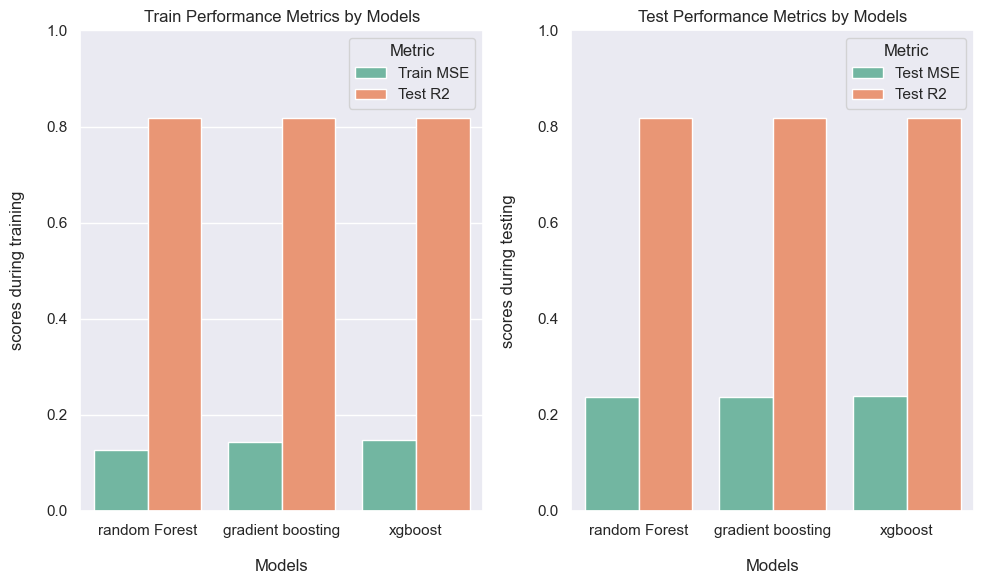

In [50]:
# Only keep relevant columns for plotting
df_melted_train =  scores_df.melt(id_vars='Model',
                    value_vars=['Train MSE', 'Test R2'],
                    var_name='Metric',
                    value_name='Score')
df_melted_test = scores_df.melt(id_vars='Model',
                    value_vars=['Test MSE', 'Test R2'],
                    var_name='Metric',
                    value_name='Score')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
# Plot
sns.barplot(data=df_melted_train, x='Model', y='Score', hue='Metric', palette='Set2', ax=ax1)
ax1.set_title("Train Performance Metrics by Models")
ax1.set_xlabel("Models", labelpad=15)
ax1.set_ylabel("scores during training", labelpad=15)
ax1.set_ylim(0, 1)
# plt.legend(title='Metric')
# plt.grid(axis='y')
# plt.tight_layout()


sns.barplot(data=df_melted_test, x='Model', y='Score', hue='Metric', palette='Set2', ax=ax2)
ax2.set_title("Test Performance Metrics by Models")
ax2.set_xlabel("Models", labelpad=15)
ax2.set_ylabel("scores during testing", labelpad=15)
ax2.set_ylim(0, 1)
plt.legend(title='Metric')
plt.xticks()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### grid search cv (hyperparameter running)

In [51]:
grid_best_params= {}
gid_search_models=[
    ("rf", RandomForestRegressor(), rf_params),
    ("gradient boosting", GradientBoostingRegressor(), gb_params),
    ("xgboost", XGBRegressor(), xg_params)
]

# FEATURE ADAPTATION TRANSFER LEARNING

In [52]:
source

,magnitude,depth,latitude,longitude,magnitude_category
0,1.43,15.12,37.672333,-121.619000,micro
1,4.90,97.07,21.514600,94.572100,light
2,0.06,4.39,37.576500,-118.859167,micro
3,0.40,1.09,37.595833,-118.994833,micro
4,0.30,7.60,39.377500,-119.845000,micro
...,...,...,...,...,...
8389,2.42,4.85,36.515499,-121.099831,micro
8390,1.40,50.00,61.498400,-149.862700,micro
8391,1.06,1.73,38.805000,-122.821503,micro
8392,1.55,29.25,34.308000,-118.635333,micro


In [53]:
ghana = ghana.drop(columns="magnitude_category", axis=1)

In [54]:
ghana.head(3)

,latitude,longitude,depth,magnitude
0,5.1,-1.3,8.0,5.5
1,5.1,-2.2,8.0,5.7
2,7.6,1.7,10.0,5.6


In [55]:
def align_columns(df):
    temp_df = df.copy()
    columns = ["latitude", "longitude", "depth", "magnitude"]
    return temp_df[columns]

In [56]:
source = align_columns(source)
source.head(3)

,latitude,longitude,depth,magnitude
0,37.672333,-121.619000,15.12,1.43
1,21.514600,94.572100,97.07,4.90
2,37.576500,-118.859167,4.39,0.06


In [57]:
ghana = align_columns(ghana)

In [58]:
ghana.head(3)

,latitude,longitude,depth,magnitude
0,5.1,-1.3,8.0,5.5
1,5.1,-2.2,8.0,5.7
2,7.6,1.7,10.0,5.6


In [59]:
global_X = source.drop("magnitude", axis=1)
global_Y = source["magnitude"]
ghana_X = ghana.drop("magnitude", axis=1)
ghana_Y = ghana["magnitude"]

In [60]:

from adapt.instance_based import TrAdaBoostR2

In [61]:
tr_scalar = StandardScaler()
global_X_scaled = tr_scalar.fit_transform(global_X)
ghana_X_scaled = tr_scalar.transform(ghana_X)

In [62]:
# Combine both
X_combined = np.vstack((global_X_scaled, ghana_X_scaled))
Y_combined = np.concatenate((global_Y, ghana_Y))


In [63]:
tradaboost_rf = TrAdaBoostR2(
    estimator=RandomForestRegressor(n_estimators= 500, min_samples_split= 10, min_samples_leaf= 2, max_depth=None, bootstrap=True, max_features="sqrt"),
    n_estimators=50,      
    Xt=ghana_X_scaled,
    yt=ghana_Y
)

# tradaboost_rf.fit(X_combined, Y_combined)
# pred_rf = tradaboost_rf.predict(ghana_X_scaled)

#Model Evaluation 
MSE_rf = mean_absolute_error(ghana_Y, pred_rf)
r2_rf = r2_score(ghana_Y, pred_rf)

print("TrAdaBoostR2 + Random Forest on Ghana")
print(f"MSE: {MSE_rf}")
print(f"R_square : {r2_rf}")

NameError: name 'pred_rf' is not defined

Text(0.5, 1.0, 'plot of predicted values against actual values by transfer learning with Random Forest')

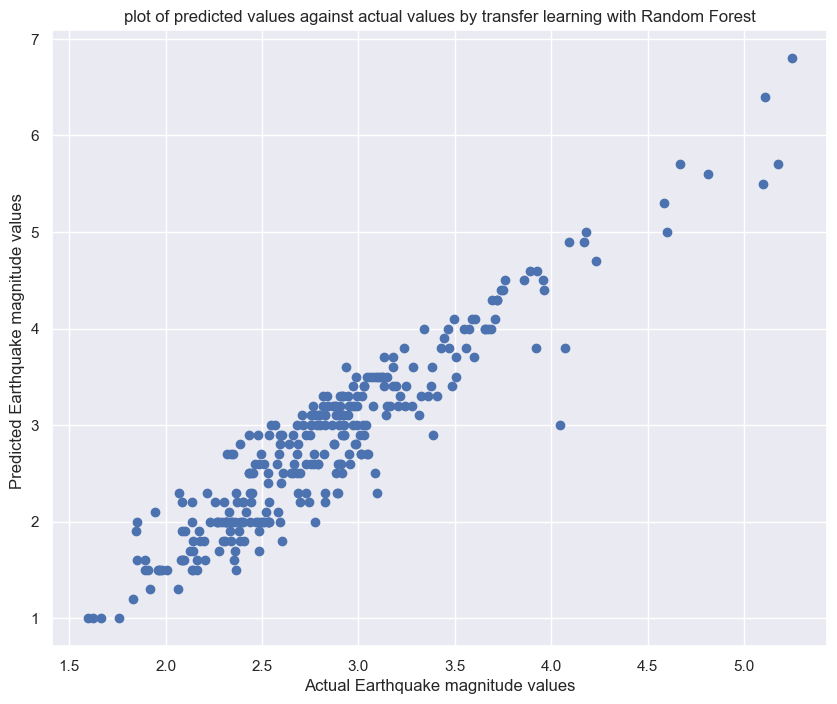

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x=pred_rf, y=ghana_Y)
plt.xlabel("Actual Earthquake magnitude values")
plt.ylabel("Predicted Earthquake magnitude values ")
plt.title("plot of predicted values against actual values by transfer learning with Random Forest")

In [ ]:
# Initialize TrAdaBoost with XGBoost
tradaboost_xgb = TrAdaBoostR2(
    estimator=XGBRegressor( subsample=0.8, reg_lambda=10, reg_alpha=0.01, n_estimators=400, max_depth=15, learning_rate=0.05, gamma=0.2, colsample_bytree=1.0, ),
    n_estimators=60,
    Xt=ghana_X_scaled,
    yt=ghana_Y
)
# tradaboost_xgb.fit(X_combined, Y_combined)
# Y_pred_xgb = tradaboost_xgb.predict(ghana_X_scaled)

## Evaluation of regression Model
MSE_xg = mean_squared_error(ghana_Y, Y_pred_xgb)
r2_xgb = r2_score(ghana_Y, Y_pred_xgb)

print("TrAdaBoostR2 + XGBoost on Ghana")
print(f"MSE: {MSE_xg:.3f}")
print(f"R_2_score : {r2_xgb:.3f}")


Iteration 0 - Error: 0.1126
Iteration 1 - Error: 0.0925
Iteration 2 - Error: 0.0840
Iteration 3 - Error: 0.0597
Iteration 4 - Error: 0.0482
Iteration 5 - Error: 0.0427
Iteration 6 - Error: 0.0380
Iteration 7 - Error: 0.0345
Iteration 8 - Error: 0.0330
Iteration 9 - Error: 0.0298
Iteration 10 - Error: 0.0261
Iteration 11 - Error: 0.0242
Iteration 12 - Error: 0.0236
Iteration 13 - Error: 0.0213
Iteration 14 - Error: 0.0197
Iteration 15 - Error: 0.0187
Iteration 16 - Error: 0.0185
Iteration 17 - Error: 0.0176
Iteration 18 - Error: 0.0173
Iteration 19 - Error: 0.0168
Iteration 20 - Error: 0.0160
Iteration 21 - Error: 0.0161
Iteration 22 - Error: 0.0162
Iteration 23 - Error: 0.0163
Iteration 24 - Error: 0.0169
Iteration 25 - Error: 0.0171
Iteration 26 - Error: 0.0178
Iteration 27 - Error: 0.0183
Iteration 28 - Error: 0.0190
Iteration 29 - Error: 0.0210
Iteration 30 - Error: 0.0213
Iteration 31 - Error: 0.0223
Iteration 32 - Error: 0.0241
Iteration 33 - Error: 0.0261
Iteration 34 - Error: 0.

Text(0.5, 1.0, 'plot of predicted values against actual values by transfer learning with XGBoost Regressor')

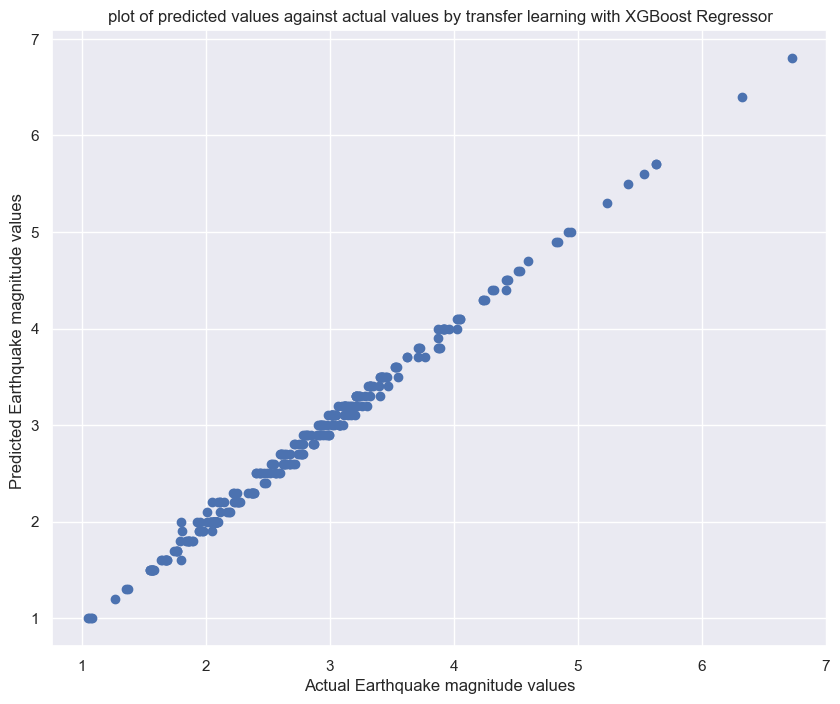

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x=Y_pred_xgb, y=ghana_Y)
plt.xlabel("Actual Earthquake magnitude values")
plt.ylabel("Predicted Earthquake magnitude values ")
plt.title("plot of predicted values against actual values by transfer learning with XGBoost Regressor")


In [ ]:
# Initialize TrAdaBoost with gradientBoost
tradaboost_gb = TrAdaBoostR2(
    estimator=GradientBoostingRegressor(subsample= 0.6, n_estimators= 400, min_samples_split= 2, min_samples_leaf=5,max_features= None, max_depth=10, learning_rate= 0.01),
    n_estimators=50,
    Xt=ghana_X_scaled,
    yt=ghana_Y
)
# tradaboost_gb.fit(X_combined, Y_combined)
# Y_pred_gb = tradaboost_gb.predict(ghana_X_scaled)

#Evaluation of regression Model
MSE_gb = mean_squared_error(ghana_Y, Y_pred_gb)
r2_gb = r2_score(ghana_Y, Y_pred_gb)

print("TrAdaBoostR2 + gradientBoost on Ghana")
print(f"MSE: {MSE_gb}")
print(f"R : {r2_gb}")


Iteration 0 - Error: 0.1345
Iteration 1 - Error: 0.1294
Iteration 2 - Error: 0.1188
Iteration 3 - Error: 0.1149
Iteration 4 - Error: 0.1157
Iteration 5 - Error: 0.1219
Iteration 6 - Error: 0.1209
Iteration 7 - Error: 0.1223
Iteration 8 - Error: 0.1238
Iteration 9 - Error: 0.1163
Iteration 10 - Error: 0.1182
Iteration 11 - Error: 0.1114
Iteration 12 - Error: 0.1152
Iteration 13 - Error: 0.1230
Iteration 14 - Error: 0.1178
Iteration 15 - Error: 0.1240
Iteration 16 - Error: 0.1202
Iteration 17 - Error: 0.1278
Iteration 18 - Error: 0.1020
Iteration 19 - Error: 0.1233
Iteration 20 - Error: 0.1132
Iteration 21 - Error: 0.1403
Iteration 22 - Error: 0.1436
Iteration 23 - Error: 0.1416
Iteration 24 - Error: 0.1224
Iteration 25 - Error: 0.1298
Iteration 26 - Error: 0.1330
Iteration 27 - Error: 0.1210
Iteration 28 - Error: 0.1405
Iteration 29 - Error: 0.1346
Iteration 30 - Error: 0.1172
Iteration 31 - Error: 0.1667
Iteration 32 - Error: 0.1182
Iteration 33 - Error: 0.1272
Iteration 34 - Error: 0.

Text(0.5, 1.0, 'plot of predicted values against actual values by transfer learning with Gradient Boosting Regressor')

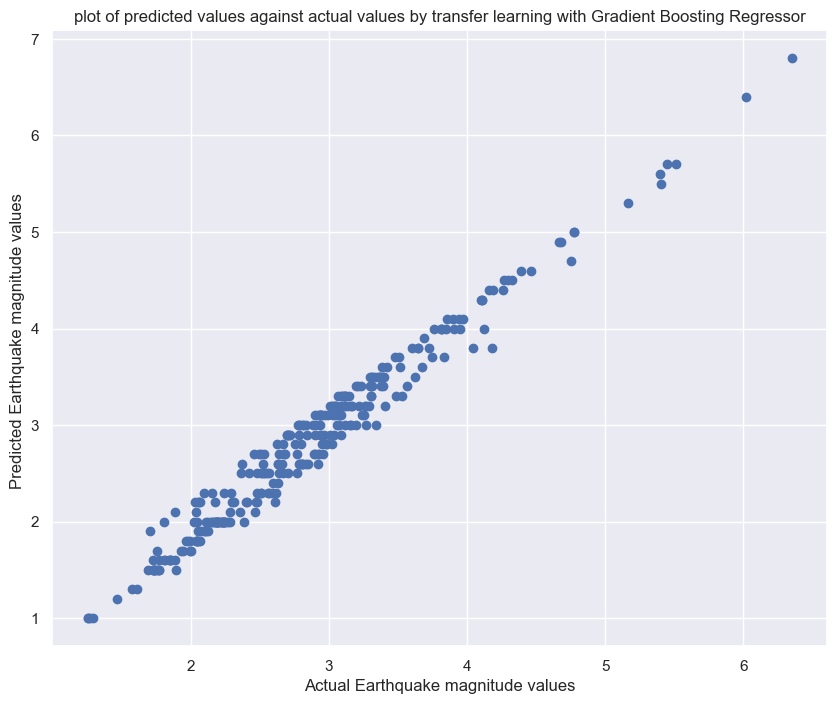

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x=Y_pred_gb , y=ghana_Y)
plt.xlabel("Actual Earthquake magnitude values")
plt.ylabel("Predicted Earthquake magnitude values ")
plt.title("plot of predicted values against actual values by transfer learning with Gradient Boosting Regressor")

In [ ]:
transfer_models_performance = {
    "models": ["Random Forest Regressor", "Gradient Boosting Regressor", "XGB Regressor"],
    "R2_score": [r2_rf, r2_gb, r2_xgb],
    "MSE" : [MSE_rf, MSE_gb, MSE_xg]
}

performance_df = pd.DataFrame(transfer_models_performance)
performance_df


,models,R2_score,MSE
0,Random Forest Regressor,0.803719,0.353704
1,Gradient Boosting Regressor,0.959021,0.036604
2,XGB Regressor,0.993930,0.005422


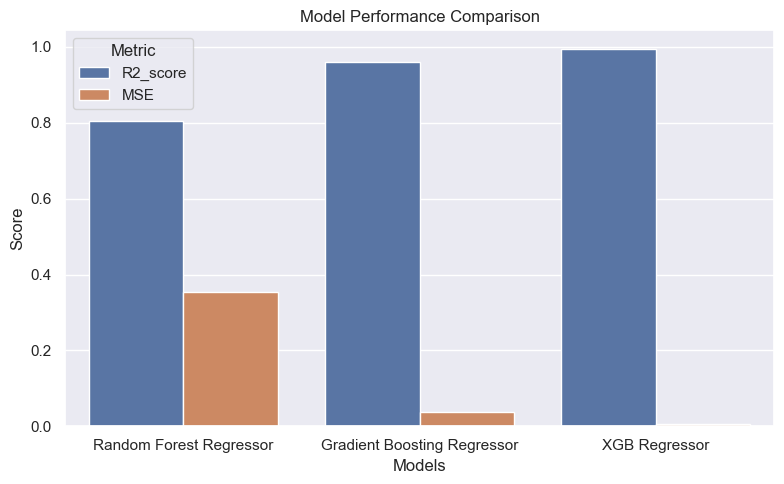

In [ ]:
# Only keep relevant columns for plotting
df_long = performance_df.melt(id_vars='models', var_name='Metric', value_name='Value')

# Create grouped bar plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_long, x='models', y='Value', hue='Metric')

# Improve aesthetics
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Models')
plt.legend(title='Metric')
plt.tight_layout()

plt.show()

